<a href="https://colab.research.google.com/github/sepriando/sataid-example/blob/main/Sataid_Level_3_RGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SATAID Level-3 : RGB
A hands-on introduction to working with SATAID (.Zxxxx) satellite files in Python.

The notebook demonstrates read sataid data and generate RGB Products.

Prepared by: **Alpon Sepriando**

Public Weather Services, BMKG — Indonesia

📧 *alpon.sepriando@bmkg.go.id*

🔗 https://github.com/sepriando/sataid-example

In [10]:
# @title Clone Example Sataid data From Github
!rm -rf /content/sataid-example
!git clone --depth 1 --filter=blob:none --sparse https://github.com/sepriando/sataid-example.git
%cd /content/sataid-example
!git sparse-checkout set data_allband
!mkdir -p /content/data_allband
!rsync -a --delete /content/sataid-example/data_allband/ /content/data_allband/

%cd /content

Cloning into 'sataid-example'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 21.06 MiB | 8.43 MiB/s, done.
Updating files: 100% (7/7), done.
/content/sataid-example
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 57.71 MiB | 10.76 MiB/s, done.
Updating files: 100% (18/18), done.
/content


In [9]:
!pip install sataid[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.9 MB/s eta 0:00:00


In [11]:
# @title Import Package
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sataid as sat    # Untuk konversi ke GeoTIFF
import rasterio         # Untuk membaca GeoTIFF dengan stabil

In [12]:
# @title User Configuration
datapath =  '/content/data_allband'
timestamp = datetime(2025, 11, 26, 7, 0)

 #--- Contoh 1: Natural Color RGB ---
produk_rgb = "Himawari-9 Natural Color RGB"
resep_rgb = {
     'R': {'band_a': 'B05', 'band_b': None, 'vmin': 0.0, 'vmax': 0.99, 'gamma': 1.0,  'inverse': False},
     'G': {'band_a': 'B04', 'band_b': None, 'vmin': 0.0, 'vmax': 1.02, 'gamma': 0.95, 'inverse': False},
     'B': {'band_a': 'B03', 'band_b': None, 'vmin': 0.0, 'vmax': 1.00, 'gamma': 1.0,  'inverse': False}}
'''
# --- Contoh 2: Volcanic Ash RGB ---
produk_rgb = "Himawari-9 BMKG's Volcanic Ash RGB"
resep_rgb = {
    'R': {'band_a': 'B13', 'band_b': 'B15', 'vmin': -1.0,   'vmax': 5.0,    'gamma': 1.0, 'inverse': True},  # S1(IR-I2)
    'G': {'band_a': 'B07', 'band_b': 'B13', 'vmin': -10.0,  'vmax': 15.0,   'gamma': 1.0, 'inverse': True},  # S2(I4-IR)
    'B': {'band_a': 'B07', 'band_b': None,  'vmin': 213.34, 'vmax': 318.37, 'gamma': 1.0, 'inverse': True}   # I4
}
'''

'\n# --- Contoh 2: Volcanic Ash RGB ---\nproduk_rgb = "Himawari-9 BMKG\'s Volcanic Ash RGB"\nresep_rgb = {\n    \'R\': {\'band_a\': \'B13\', \'band_b\': \'B15\', \'vmin\': -1.0,   \'vmax\': 5.0,    \'gamma\': 1.0, \'inverse\': True},  # S1(IR-I2)\n    \'G\': {\'band_a\': \'B07\', \'band_b\': \'B13\', \'vmin\': -10.0,  \'vmax\': 15.0,   \'gamma\': 1.0, \'inverse\': True},  # S2(I4-IR)\n    \'B\': {\'band_a\': \'B07\', \'band_b\': None,  \'vmin\': 213.34, \'vmax\': 318.37, \'gamma\': 1.0, \'inverse\': True}   # I4\n}\n'

In [13]:
# @title Functions Definitions

def muat_band_satelit(datapath, daftar_band, dt_object):
    """
    Memuat data sataid, mengonversi ke GeoTIFF (jika belum ada),
    lalu membaca datanya menggunakan rasterio untuk kestabilan.
    """
    kamus_band = {}
    lat, lon = None, None
    str_time = dt_object.strftime('%Y%m%d.Z%H%M')

    for band in daftar_band:
        nama_file_sataid = f"H09_{band}_Indonesia_{str_time}"
        filepath_sataid = os.path.join(datapath, nama_file_sataid)
        filepath_tif = filepath_sataid + ".tif"  # Nama output GeoTIFF

        if os.path.exists(filepath_sataid):
            # 1. KONVERSI KE GEOTIFF MENGGUNAKAN PACKAGE SATAID
            if not os.path.exists(filepath_tif):
                print(f"-> Mengonversi {band} ke format GeoTIFF...")
                data_sataid = sat.read_sataid(filepath_sataid)
                data_sataid.to_geotiff(filepath_tif)

            # 2. BACA FILE GEOTIFF MENGGUNAKAN RASTERIO
            print(f"-> Membaca {band} dengan Rasterio...")
            with rasterio.open(filepath_tif) as src:
                # Membaca data ke dalam array numpy float32
                data_array = src.read(1).astype(np.float32)
                kamus_band[band] = data_array

                # Mengambil metadata batas geografis (hanya perlu dilakukan sekali)
                if lat is None:
                    bounds = src.bounds
                    lon = np.linspace(bounds.left, bounds.right, src.width)
                    lat = np.linspace(bounds.bottom, bounds.top, src.height)
        else:
            print(f"[Peringatan] File SATAID tidak ditemukan: {filepath_sataid}")

    return kamus_band, lat, lon

def proses_channel(data, vmin=None, vmax=None, gamma=1.0, inverse=False):
    """Menormalisasi nilai fisis band menjadi skala 0 - 1 untuk warna."""
    if vmin is None:
        vmin = data.min()
    if vmax is None:
        vmax = data.max()

    denom = vmax - vmin if vmax != vmin else 1e-5
    scaled = (data - vmin) / denom

    if inverse:
        scaled = 1.0 - scaled

    scaled = np.clip(scaled, 0, 1)
    return scaled ** gamma

def plot_rgb_composite(rgb_data, lat, lon, nama_produk, dt_object):
    """Fungsi visualisasi peta menggunakan Cartopy."""
    lebar_derajat = lon.max() - lon.min()
    tinggi_derajat = lat.max() - lat.min()
    ar_map = lebar_derajat / tinggi_derajat

    margin_left = 0.06
    margin_right = 0.98
    margin_bottom = 0.06
    margin_top = 0.94

    w_frac = margin_right - margin_left
    h_frac = margin_top - margin_bottom

    h_fig = 7.5
    w_fig = h_fig * ar_map * (h_frac / w_frac)

    fig, ax = plt.subplots(figsize=(w_fig, h_fig), subplot_kw={'projection': ccrs.PlateCarree()})
    plt.subplots_adjust(left=margin_left, right=margin_right, bottom=margin_bottom, top=margin_top)

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Menampilkan citra komposit RGB
    ax.imshow(
        rgb_data,
        extent=(lon.min(), lon.max(), lat.min(), lat.max()),
        origin='upper',
        transform=ccrs.PlateCarree()
    )

    # Menambahkan fitur peta geografis
    ax.coastlines(resolution='10m', color='white', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.5)

    waktu_str = dt_object.strftime('%Y-%m-%d %H:%M UTC')
    ax.text(0.0, 1.01, nama_produk, transform=ax.transAxes,
            va='bottom', ha='left', fontsize=11, weight='bold')
    ax.text(1.0, 1.01, waktu_str, transform=ax.transAxes,
            va='bottom', ha='right', fontsize=11, weight='bold')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    plt.show()

-> Mengonversi B05 ke format GeoTIFF...
Saving data to GeoTIFF: /content/data_allband/H09_B05_Indonesia_20251126.Z0700.tif
-> Membaca B05 dengan Rasterio...
-> Mengonversi B04 ke format GeoTIFF...
Saving data to GeoTIFF: /content/data_allband/H09_B04_Indonesia_20251126.Z0700.tif
-> Membaca B04 dengan Rasterio...
-> Mengonversi B03 ke format GeoTIFF...
Saving data to GeoTIFF: /content/data_allband/H09_B03_Indonesia_20251126.Z0700.tif
-> Membaca B03 dengan Rasterio...


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


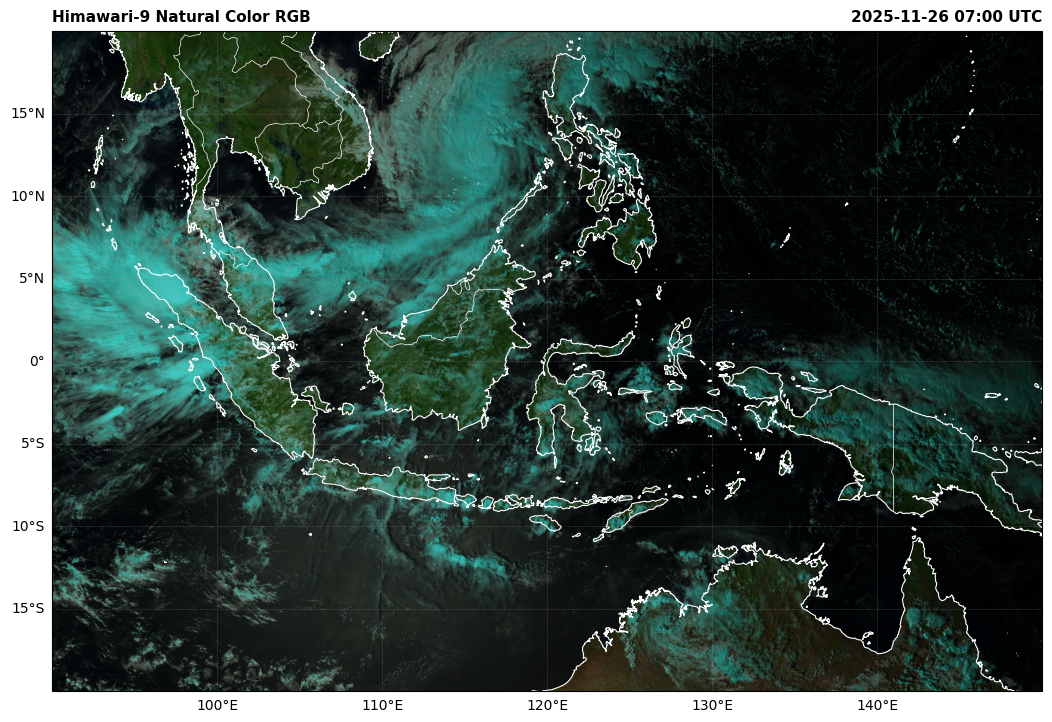

In [14]:
# @title Main Workflow Caller

# 1. Otomatisasi Ekstraksi Daftar Band dari Resep
band_dibutuhkan = []
for komponen in resep_rgb.values():
    if komponen['band_a'] and komponen['band_a'] not in band_dibutuhkan:
        band_dibutuhkan.append(komponen['band_a'])
    if komponen['band_b'] and komponen['band_b'] not in band_dibutuhkan:
        band_dibutuhkan.append(komponen['band_b'])

# 2. Panggil fungsi loader data satelit (SATAID -> GeoTIFF -> Rasterio)
data_satelit, lat, lon = muat_band_satelit(datapath, band_dibutuhkan, timestamp)

# ------------------------------------------------------------------------------
# KOREKSI SKALA & SATUAN OTOMATIS (ALBEDO & TEMPERATURE)
# ------------------------------------------------------------------------------
if data_satelit:
    band_reflectance = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06']
    band_thermal = [f"B{i:02d}" for i in range(7, 17)]

    for band in data_satelit:
        # A. Koreksi untuk Saluran Tampak / Albedo
        if band in band_reflectance:
            if data_satelit[band].max() > 1.0:
                data_satelit[band] = data_satelit[band] / 100.0

        # B. Koreksi untuk Saluran Thermal
        elif band in band_thermal:
            if data_satelit[band].mean() < 150:
                data_satelit[band] = data_satelit[band] + 273.15

# 3. Lakukan kalkulasi matematis & standardisasi secara otomatis berdasarkan resep
if data_satelit:
    rgb_channels = {}

    for warna, cfg in resep_rgb.items():
        if cfg['band_b'] is not None:
            data_fisis = data_satelit[cfg['band_a']] - data_satelit[cfg['band_b']]
        else:
            data_fisis = data_satelit[cfg['band_a']]

        rgb_channels[warna] = proses_channel(
            data_fisis,
            vmin=cfg['vmin'],
            vmax=cfg['vmax'],
            gamma=cfg['gamma'],
            inverse=cfg['inverse']
        )

    # 4. Satukan channel R, G, B hasil pemrosesan otomatis
    rgb_composite = np.dstack([rgb_channels['R'], rgb_channels['G'], rgb_channels['B']])

    # 5. Tampilkan ke peta
    plot_rgb_composite(rgb_composite, lat, lon, produk_rgb, timestamp)

else:
    print("Eksekusi grafik dibatalkan karena file tidak lengkap.")